# Model Interpretability

**Goal**: Make the model's predictions transparent and explainable for stakeholders.

**Approach**:
1. SHAP values — global feature importance + local explanations
2. Partial Dependence Plots — how individual features affect predictions
3. Risk profile example — what a supplier risk report would look like

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from scipy.stats import randint, uniform

DATA_PROCESSED = Path("../data/processed")

## 1. Retrain best model and compute SHAP values

In [2]:
# Load and prepare data (same as modeling notebook)
df = pd.read_parquet(DATA_PROCESSED / "features.parquet")
df["year"] = df["inspection_date"].dt.year

CATEGORICAL_FEATURES = ["product_type", "country", "project_area"]
DROP_COLS = ["inspection_id", "fei_number", "inspection_date", "target_oai", "year"]

REDUNDANT_FOR_TREES = [
    "has_warning_letter", "has_recall", "has_published_483",
    "pct_oai", "pct_vai",
]
NUMERIC_FEATURES = [
    c for c in df.columns
    if c not in DROP_COLS + CATEGORICAL_FEATURES + REDUNDANT_FOR_TREES
]

label_encoders = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    le.fit(df[col].astype(str))
    df[col + "_encoded"] = le.transform(df[col].astype(str))
    label_encoders[col] = le

ENCODED_CATS = [c + "_encoded" for c in CATEGORICAL_FEATURES]
FEATURES = NUMERIC_FEATURES + ENCODED_CATS

train = df[df["year"] < 2025]
test = df[df["year"] >= 2025]

X_train = train[FEATURES].values
X_test = test[FEATURES].values
y_train = train["target_oai"].values
y_test = test["target_oai"].values

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Features: {FEATURES}")

Train: (154386, 22), Test: (10624, 22)
Features: ['n_prior_inspections', 'n_prior_oai', 'n_prior_vai', 'n_prior_nai', 'days_since_last_inspection', 'last_classification_oai', 'last_classification_vai', 'trend_worsening', 'recent_oai_rate', 'total_prior_citations', 'avg_citations_per_inspection', 'max_citations_single_inspection', 'total_unique_cfr_violated', 'n_warning_letters', 'days_since_last_wl', 'n_recalls', 'n_class_I_recalls', 'n_class_II_recalls', 'n_published_483s', 'product_type_encoded', 'country_encoded', 'project_area_encoded']


In [3]:
# Train the best model (XGBoost weighted — best ROC-AUC)
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=n_neg / n_pos,
    random_state=42,
    eval_metric="aucpr",
    early_stopping_rounds=20,
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print("Model trained.")

Model trained.


## 2. SHAP — Global Feature Importance

In [4]:
# Compute SHAP values on test set
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Create a DataFrame for readability
X_test_df = pd.DataFrame(X_test, columns=FEATURES)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (10624, 22)


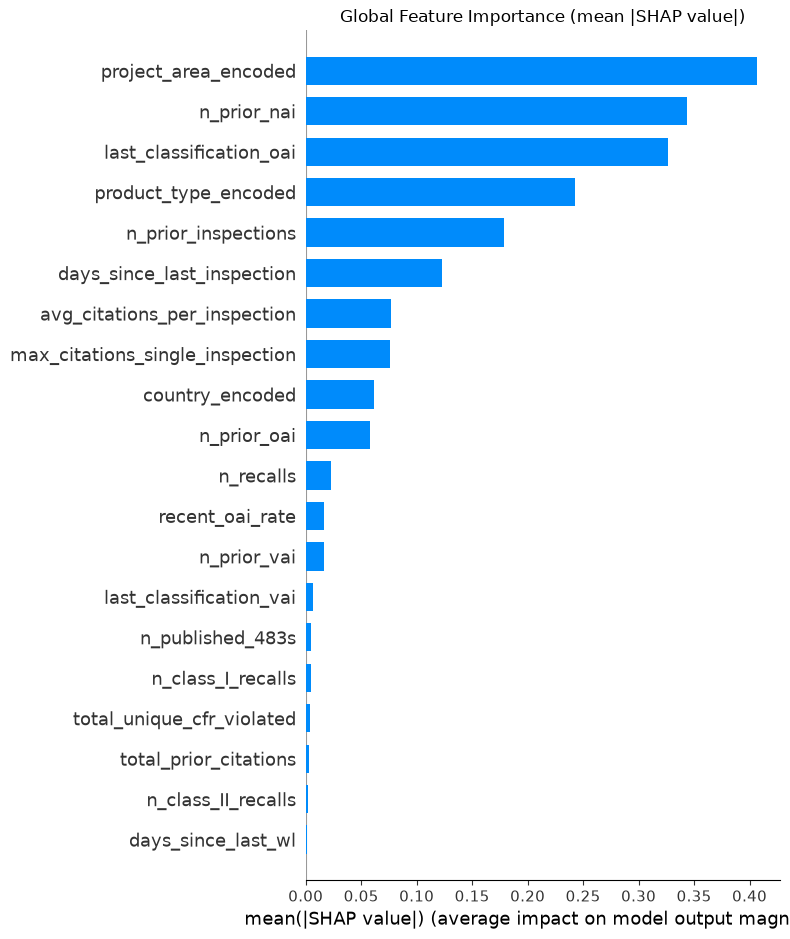

In [5]:
# Global feature importance (mean |SHAP|)
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_df, plot_type="bar", show=False, max_display=20)
plt.title("Global Feature Importance (mean |SHAP value|)")
plt.tight_layout()
plt.savefig("../reports/fig_shap_global_importance.png", dpi=150, bbox_inches="tight")
plt.show()

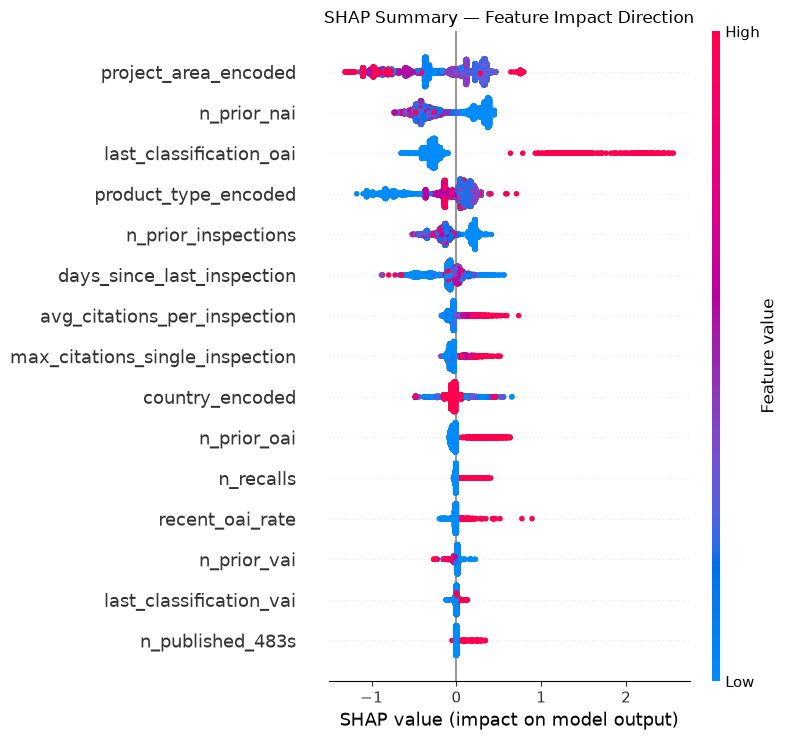

In [6]:
# SHAP summary (beeswarm) — shows direction of impact
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_df, show=False, max_display=15)
plt.title("SHAP Summary — Feature Impact Direction")
plt.tight_layout()
plt.savefig("../reports/fig_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. SHAP — Local Explanations

Show WHY the model flagged (or didn't flag) specific facilities.

In [7]:
# Find a true positive (OAI correctly predicted) and a false negative (OAI missed)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# True positive: high probability + actually OAI
tp_mask = (y_test == 1) & (y_pred_proba > 0.5)
tp_indices = np.where(tp_mask)[0]

# False negative: low probability but actually OAI
fn_mask = (y_test == 1) & (y_pred_proba < 0.2)
fn_indices = np.where(fn_mask)[0]

print(f"True positives (high confidence): {len(tp_indices)}")
print(f"False negatives (missed OAIs): {len(fn_indices)}")

True positives (high confidence): 419
False negatives (missed OAIs): 7


TRUE POSITIVE — Facility predicted as high risk (prob: 0.519)
Actual outcome: OAI = 1



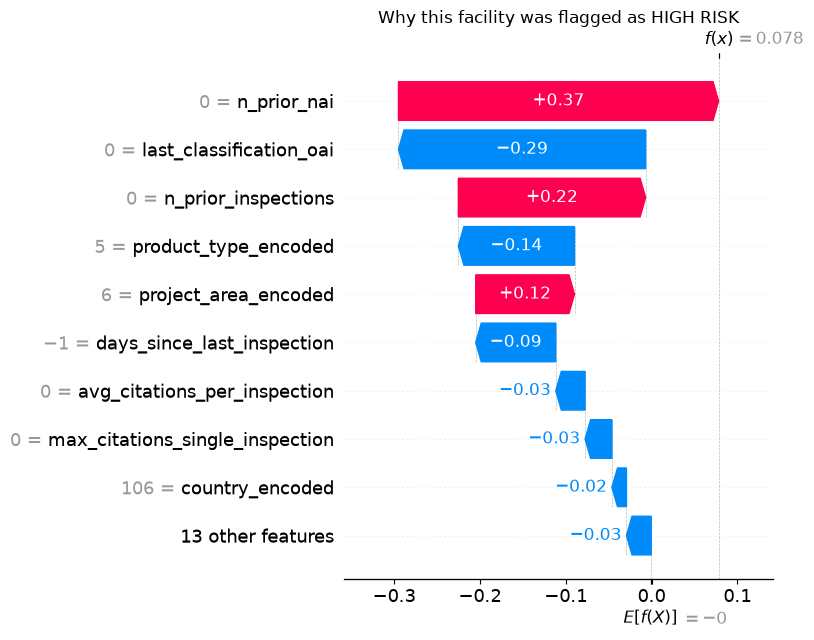

In [8]:
# Explain a True Positive
if len(tp_indices) > 0:
    idx = tp_indices[0]
    print(f"TRUE POSITIVE — Facility predicted as high risk (prob: {y_pred_proba[idx]:.3f})")
    print(f"Actual outcome: OAI = {y_test[idx]}")
    print()
    shap.waterfall_plot(shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_df.iloc[idx],
        feature_names=FEATURES,
    ), show=False)
    plt.title("Why this facility was flagged as HIGH RISK")
    plt.tight_layout()
    plt.savefig("../reports/fig_shap_true_positive.png", dpi=150, bbox_inches="tight")
    plt.show()

FALSE NEGATIVE — Facility predicted as low risk (prob: 0.112)
Actual outcome: OAI = 1



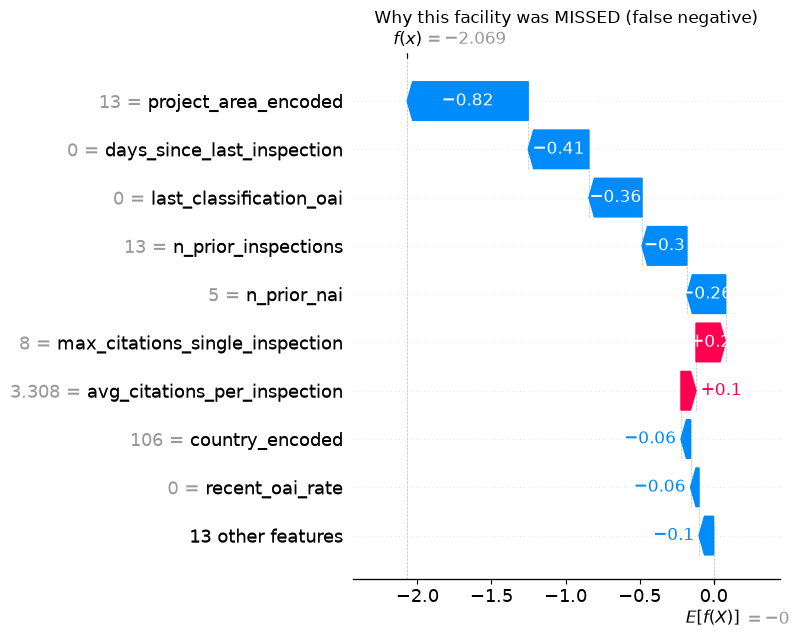

In [9]:
# Explain a False Negative
if len(fn_indices) > 0:
    idx = fn_indices[0]
    print(f"FALSE NEGATIVE — Facility predicted as low risk (prob: {y_pred_proba[idx]:.3f})")
    print(f"Actual outcome: OAI = {y_test[idx]}")
    print()
    shap.waterfall_plot(shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_df.iloc[idx],
        feature_names=FEATURES,
    ), show=False)
    plt.title("Why this facility was MISSED (false negative)")
    plt.tight_layout()
    plt.savefig("../reports/fig_shap_false_negative.png", dpi=150, bbox_inches="tight")
    plt.show()

## 4. Partial Dependence — Key Features

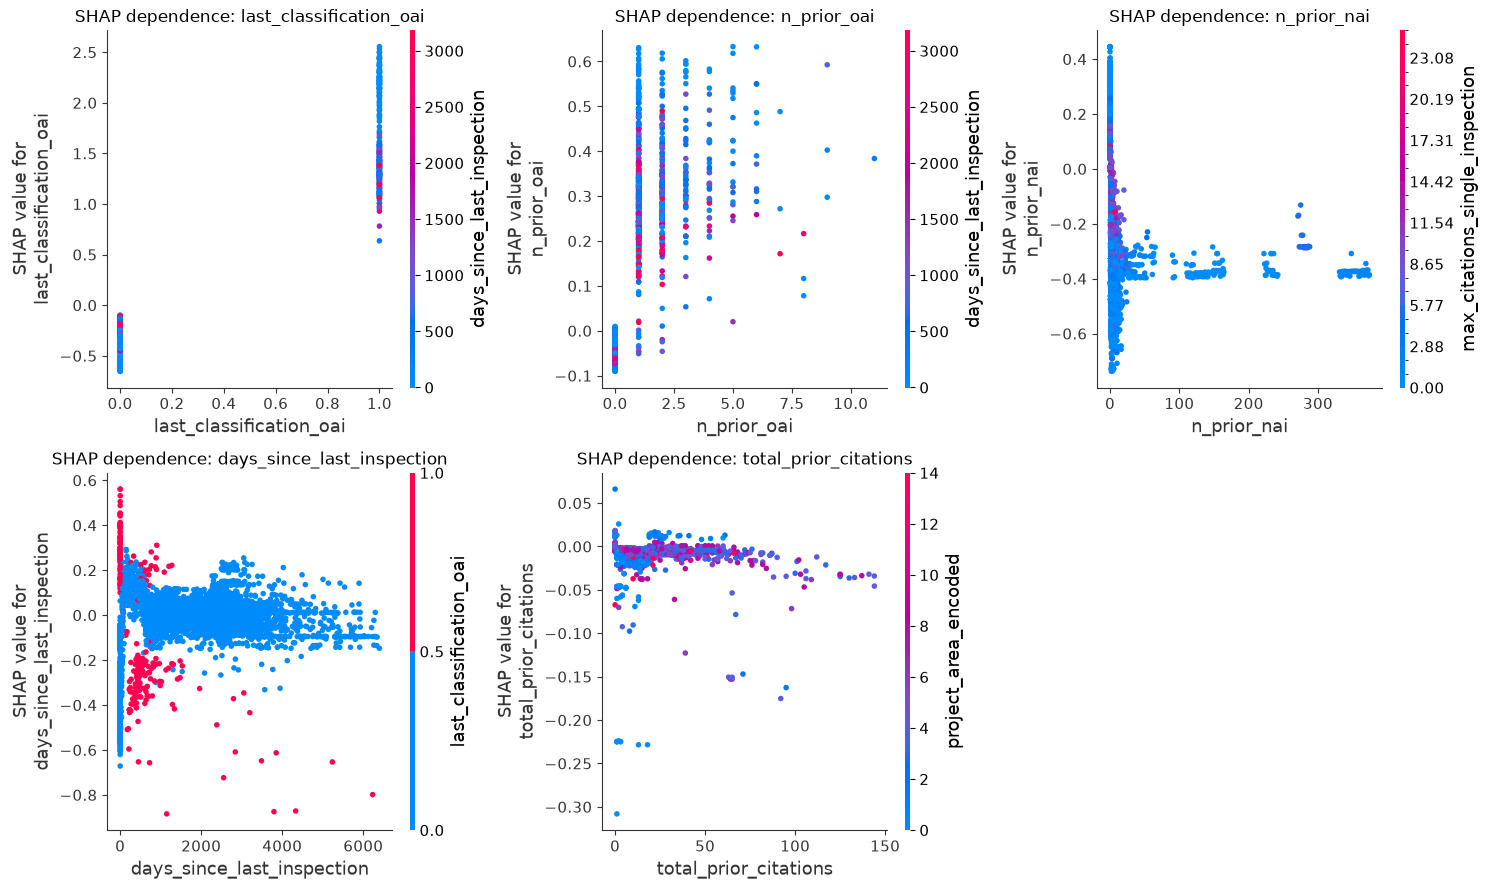

In [10]:
# Top features to plot
top_features = ["last_classification_oai", "n_prior_oai", "n_prior_nai",
                "days_since_last_inspection", "total_prior_citations"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    feat_idx = FEATURES.index(feat)
    shap.dependence_plot(feat_idx, shap_values, X_test_df, ax=axes[i], show=False)
    axes[i].set_title(f"SHAP dependence: {feat}")

axes[-1].axis("off")
plt.tight_layout()
plt.savefig("../reports/fig_shap_dependence.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Risk Profile Example

What a supplier risk report would look like in production.

In [11]:
# Pick a high-risk facility from the test set
high_risk_idx = np.argsort(y_pred_proba)[-5:]  # Top 5 riskiest

print("=" * 70)
print("SUPPLIER RISK REPORT — Top 5 Highest Risk Facilities")
print("=" * 70)

for rank, idx in enumerate(reversed(high_risk_idx), 1):
    row = test.iloc[idx]
    prob = y_pred_proba[idx]
    actual = "OAI" if y_test[idx] == 1 else "Non-OAI"

    print(f"\n{'─' * 70}")
    print(f"  RANK #{rank} | Risk Score: {prob:.1%} | Actual Outcome: {actual}")
    print(f"{'─' * 70}")
    print(f"  FEI Number:     {row['fei_number']}")
    print(f"  Product Type:   {row['product_type']}")
    print(f"  Country:        {row['country']}")
    print(f"  Project Area:   {row['project_area']}")
    print(f"  Inspection Date:{row['inspection_date'].strftime('%Y-%m-%d')}")
    print(f"  ")
    print(f"  Risk Drivers:")

    # Top SHAP contributors for this prediction
    shap_idx = test.index.get_loc(test.index[idx]) if hasattr(test.index, 'get_loc') else idx
    feature_contributions = list(zip(FEATURES, shap_values[idx]))
    feature_contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    for feat_name, shap_val in feature_contributions[:5]:
        direction = "↑" if shap_val > 0 else "↓"
        feat_value = X_test_df.iloc[idx][feat_name]
        print(f"    {direction} {feat_name} = {feat_value:.0f} (impact: {shap_val:+.3f})")

print(f"\n{'═' * 70}")

SUPPLIER RISK REPORT — Top 5 Highest Risk Facilities

──────────────────────────────────────────────────────────────────────
  RANK #1 | Risk Score: 95.2% | Actual Outcome: OAI
──────────────────────────────────────────────────────────────────────
  FEI Number:     3007058211
  Product Type:   Veterinary
  Country:        France
  Project Area:   Monitoring of Marketed Animal Drugs, Feed, and Devices
  Inspection Date:2026-01-22
  
  Risk Drivers:
    ↑ last_classification_oai = 1 (impact: +2.000)
    ↑ n_prior_oai = 2 (impact: +0.535)
    ↑ days_since_last_inspection = 0 (impact: +0.209)
    ↓ n_prior_inspections = 7 (impact: -0.108)
    ↑ n_prior_nai = 0 (impact: +0.091)

──────────────────────────────────────────────────────────────────────
  RANK #2 | Risk Score: 95.0% | Actual Outcome: OAI
──────────────────────────────────────────────────────────────────────
  FEI Number:     3013723309
  Product Type:   Veterinary
  Country:        China
  Project Area:   Monitoring of Marketed 

## 6. Key Takeaways for Stakeholders

### How to communicate model decisions:

1. **Risk Score**: Each supplier gets a probability (0-100%) of receiving OAI on next inspection.
   This is NOT a certainty — it's a signal for prioritizing human review.

2. **Transparency**: For every flagged supplier, we provide:
   - The specific risk drivers (which features pushed the score up/down)
   - Historical context (how many OAIs, when, what violations)
   - Confidence level (high score = multiple converging risk signals)

3. **Limitations to communicate clearly**:
   - The model cannot predict first-time offenders with no prior history
   - Public data is incomplete (the FDA inspection database is not comprehensive)
   - The model captures correlation, not causation — a high score means "looks like other OAI cases", not "definitely will get OAI"

4. **Recommended workflow**:
   ```
   Model flags supplier → Analyst reviews risk drivers →
   Decision: request additional audit / accept risk / monitor closely
   ```

5. **Regulatory compliance**:
   - Every prediction is fully explainable (SHAP values)
   - No black-box decisions — human always in the loop
   - Audit trail: model version, features used, threshold applied, all logged